# Lab 4: Linear & Logistic Regression

## Part 0: Setup

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score


## Part 1: Simple vs Multiple Linear Regression

In [ ]:
# create dummy data for simple and multiple LR
np.random.seed(42)

X_simple = np.arange(1, 21).reshape(-1, 1)
y_simple = 2.5 * X_simple + 10 + np.random.randn(20, 1) * 3

X_multi = np.hstack([
    X_simple,
    np.random.randint(1, 10, size=(20, 1))
])
y_multi = 3 * X_multi[:, 0] + 1.5 * X_multi[:, 1] + 5 + np.random.randn(20) * 2

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)


LinearRegression()

## Part 2: Sum of Squared Error (SSE)

In [ ]:

y_pred = simple_model.predict(X_simple)
errors = y_simple - y_pred

SSE = np.sum(errors ** 2)
MSE = mean_squared_error(y_simple, y_pred)

SSE, MSE


(np.float64(98.27278311522466), 4.913639155761233)

## Part 3: Slope and Intercept Visualization

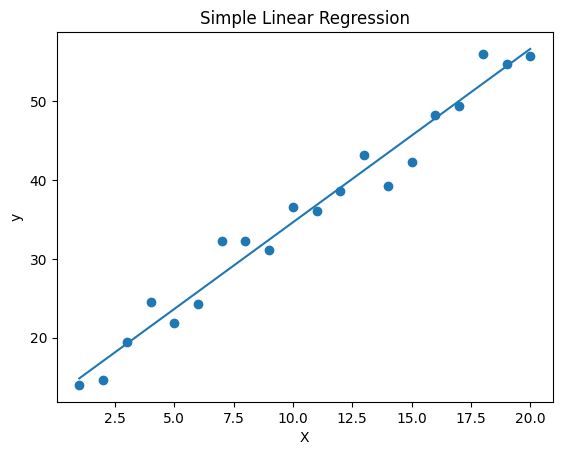

(array([[2.20130573]]), array([12.62239417]))

In [ ]:

plt.scatter(X_simple, y_simple)
plt.plot(X_simple, y_pred)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.show()

simple_model.coef_, simple_model.intercept_


## Part 4: Preventing Overfitting

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

multi_model.fit(X_train, y_train)

train_mse = mean_squared_error(y_train, multi_model.predict(X_train))
test_mse = mean_squared_error(y_test, multi_model.predict(X_test))

train_mse, test_mse


(1.9731280419616635, 6.455589878512861)

## Part 5: Logistic Regression

In [ ]:

X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

log_model = LogisticRegression()
log_model.fit(X, y)

y_pred = log_model.predict(X)
accuracy_score(y, y_pred)


1.0

## Extra 1: Ridge Regression

In [ ]:

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_train_mse = mean_squared_error(y_train, ridge.predict(X_train))
ridge_test_mse = mean_squared_error(y_test, ridge.predict(X_test))

ridge_train_mse, ridge_test_mse


(1.976792367814633, 6.328041873969834)

## Extra 2: Logistic Regression Decision Boundary

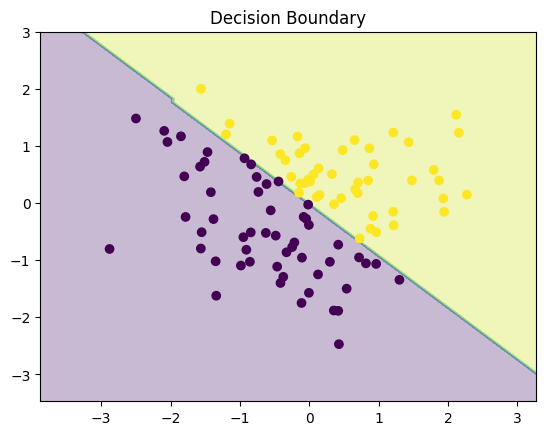

In [ ]:

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
)

Z = log_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Decision Boundary")
plt.show()


## Reflections

1.   Did Ridge regression improve the results compared to linear regression?
2.   Why is linear regression unsuitable for classification?


